In [1]:
!pip install numpy pamdas scikit-fuzzy matplotlib requests

In [2]:
import pandas as pd

In [3]:
# ganti path sesuai lokasi file kamu
data = pd.read_csv("./test-data.csv")

# tampilkan 5 baris pertama
data.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


In [4]:
# Feature Selection dan Preprocessing
import numpy as np

# buat kolom umur mobil (Car_Age)
data['Car_Age'] = 2025 - data['Year']

# ambil kolom yang relevan
selected = data[['Year', 'Kilometers_Driven', 'Car_Age']].copy()
selected.head()


,Year,Kilometers_Driven,Car_Age
0,2014,40929,11
1,2013,54493,12
2,2017,34000,8
3,2012,139000,13
4,2014,29000,11


C:\Users\DELL\anaconda3\envs\env\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


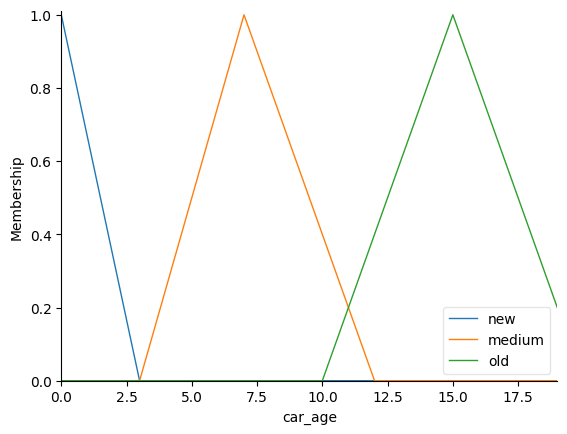

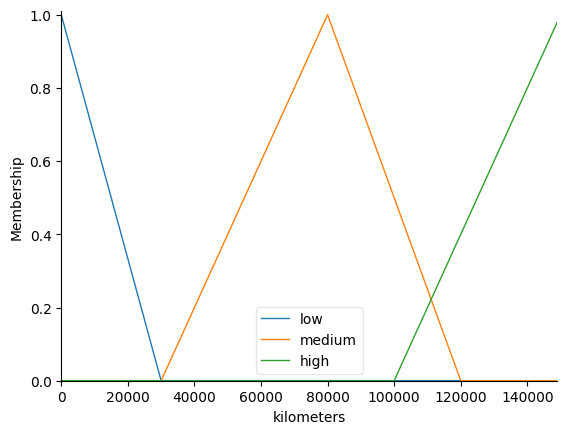

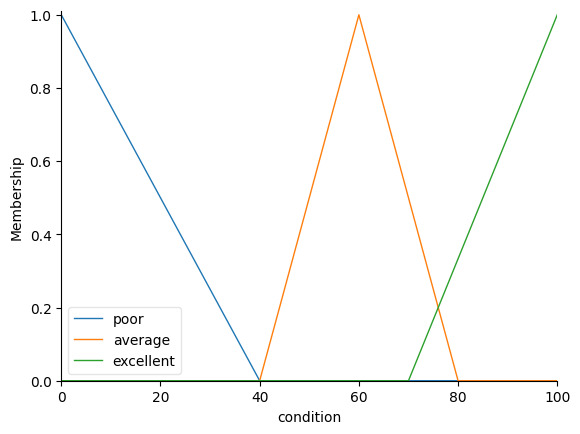

In [5]:
# Membership Function Design
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# variabel input dan output
car_age = ctrl.Antecedent(np.arange(0, 20, 1), 'car_age')
km = ctrl.Antecedent(np.arange(0, 150000, 1000), 'kilometers')
condition = ctrl.Consequent(np.arange(0, 101, 1), 'condition')

# membership function untuk car_age
car_age['new'] = fuzz.trimf(car_age.universe, [0, 0, 3])
car_age['medium'] = fuzz.trimf(car_age.universe, [3, 7, 12])
car_age['old'] = fuzz.trimf(car_age.universe, [10, 15, 20])

# membership function untuk kilometers
km['low'] = fuzz.trimf(km.universe, [0, 0, 30000])
km['medium'] = fuzz.trimf(km.universe, [30000, 80000, 120000])
km['high'] = fuzz.trimf(km.universe, [100000, 150000, 150000])

# membership function untuk condition
condition['poor'] = fuzz.trimf(condition.universe, [0, 0, 40])
condition['average'] = fuzz.trimf(condition.universe, [40, 60, 80])
condition['excellent'] = fuzz.trimf(condition.universe, [70, 100, 100])

# visualisasi membership function
car_age.view()
km.view()
condition.view()


In [6]:
# Fuzzy Rules
rule1 = ctrl.Rule(car_age['new'] & km['low'], condition['excellent'])
rule2 = ctrl.Rule(car_age['medium'] & km['medium'], condition['average'])
rule3 = ctrl.Rule(car_age['old'] & km['high'], condition['poor'])
rule4 = ctrl.Rule(car_age['medium'] & km['low'], condition['excellent'])
rule5 = ctrl.Rule(car_age['old'] & km['medium'], condition['average'])

condition_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
condition_sim = ctrl.ControlSystemSimulation(condition_ctrl)


In [8]:
# Apply Fuzzy Logic to Dataset
scores = []

for i, row in selected.iterrows():
    condition_sim = ctrl.ControlSystemSimulation(condition_ctrl)
    
    km_val = min(max(row['Kilometers_Driven'], 0), 150000)
    age_val = min(max(row['Car_Age'], 0), 20)
    
    condition_sim.input['car_age'] = age_val
    condition_sim.input['kilometers'] = km_val
    
    condition_sim.compute()
    if 'condition' in condition_sim.output:
        scores.append(condition_sim.output['condition'])
    else:
        scores.append(None)

selected['Condition_Score'] = scores
selected.head()


,Year,Kilometers_Driven,Car_Age,Condition_Score
0,2014,40929,11,60.000000
1,2013,54493,12,60.000000
2,2017,34000,8,60.000000
3,2012,139000,13,14.857143
4,2014,29000,11,85.248588


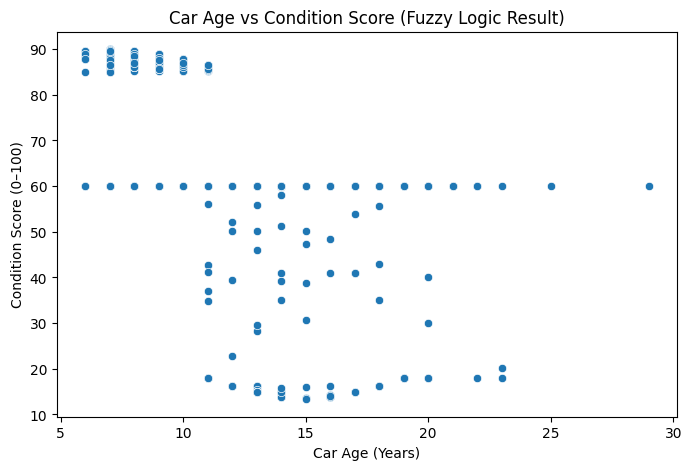

In [9]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x='Car_Age', y='Condition_Score', data=selected)
plt.title("Car Age vs Condition Score (Fuzzy Logic Result)")
plt.xlabel("Car Age (Years)")
plt.ylabel("Condition Score (0–100)")
plt.show()


In [10]:
# Save to CSV
selected.to_csv("car_condition_fuzzy_result.csv", index=False)
print("File berhasil disimpan: car_condition_fuzzy_result.csv")


File berhasil disimpan: car_condition_fuzzy_result.csv
